Using `from sklearn.datasets.make_regression`, we will create a dataset on which to train a linear regression model. This dataset will contain 1,000 data points and 6 features. The graphs below visualise the relationship between each feature and the target value.

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt


Shape of X: (1000, 6)
Shape of y: (1000,)





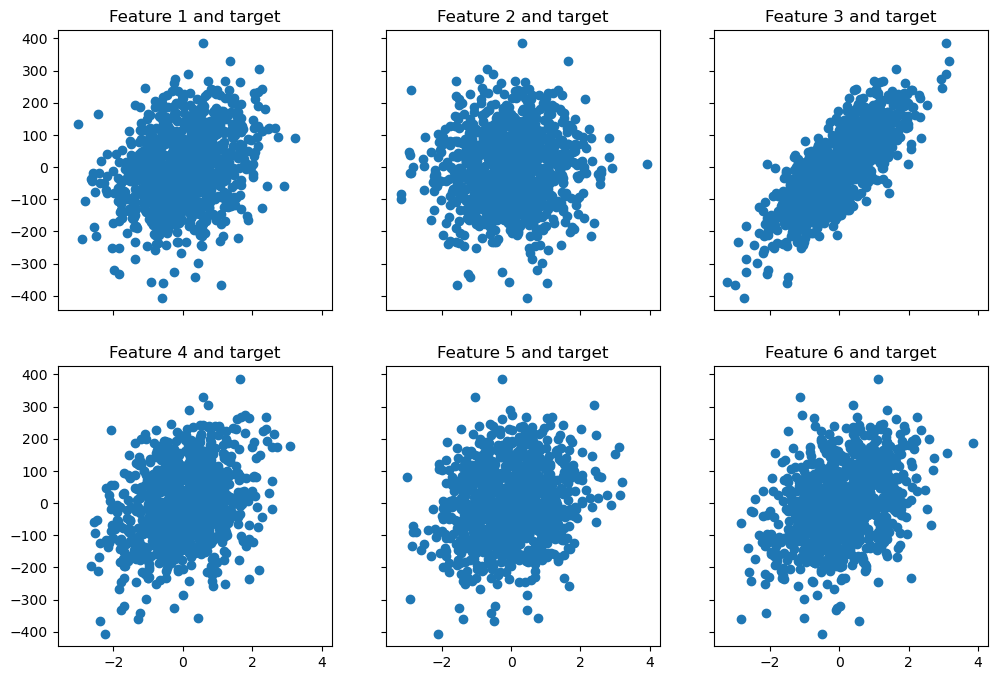

In [2]:
X, y = make_regression(n_samples=1000, n_features=6, noise=30, random_state=42)

print(f'\nShape of X: {X.shape}\nShape of y: {y.shape}\n\n\n')

fig, axs = plt.subplots(2, 3, sharey=True, sharex=True, figsize=(12,8))
axes_flatten = axs.flatten()

for feature_idx in range(6):
    axes_flatten[feature_idx].scatter(X[:, feature_idx], y)
    axes_flatten[feature_idx].set_title(f'Feature {feature_idx+1} and target')

Using the `model_selection.train_test_split` function, we will split the dataset into a training set and a test set, reserving **80%** of the data for training and **20%** for testing. We will visualize all of this below.

In [3]:
from sklearn.model_selection import train_test_split

Shape of X train: (800, 6)
Shape of y train: (800,)
Shape of X test: (200, 6)
Shape of y test: (200,)




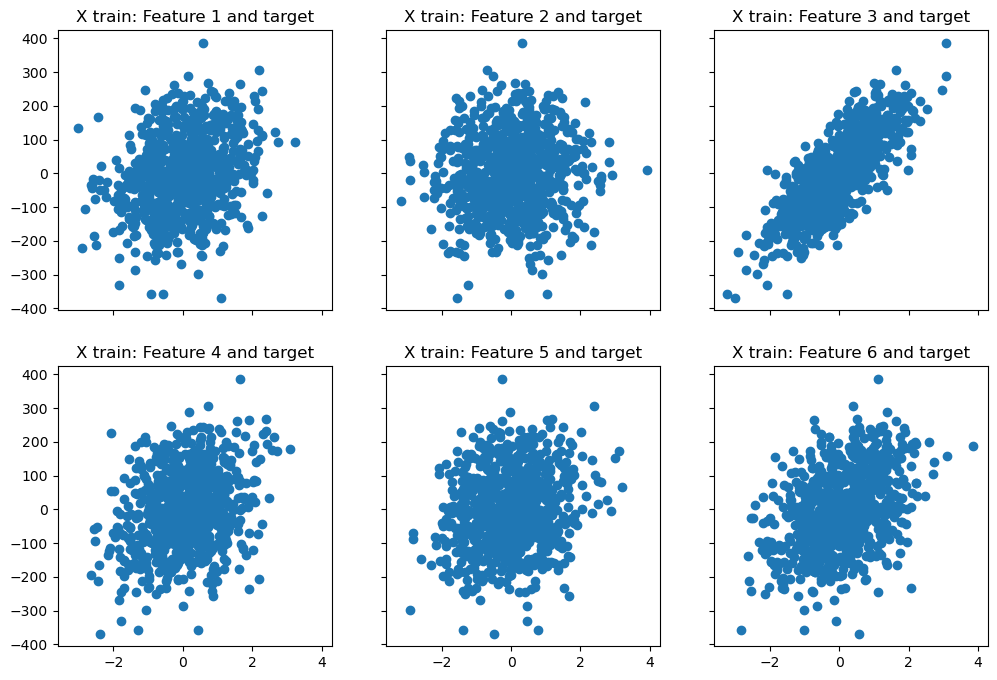

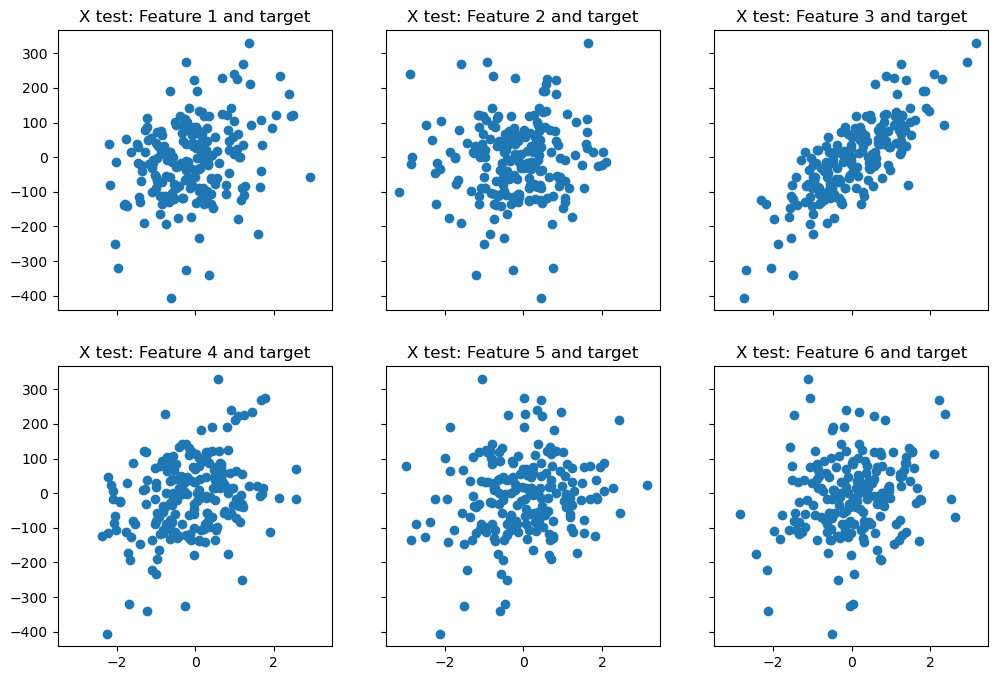

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print(f'Shape of X train: {X_train.shape}\nShape of y train: {y_train.shape}\nShape of X test: {X_test.shape}\nShape of y test: {y_test.shape}\n\n')

fig, axs = plt.subplots(2, 3, sharey=True, sharex=True, figsize=(12,8))
axes_flatten = axs.flatten()

for feature_idx in range(6):
    axes_flatten[feature_idx].scatter(X_train[:, feature_idx], y_train)
    axes_flatten[feature_idx].set_title(f'X train: Feature {feature_idx+1} and target')

fig, axs = plt.subplots(2, 3, sharey=True, sharex=True, figsize=(12,8))
axes_flatten = axs.flatten()

for feature_idx in range(6):
    axes_flatten[feature_idx].scatter(X_test[:, feature_idx], y_test)
    axes_flatten[feature_idx].set_title(f'X test: Feature {feature_idx+1} and target')

Let's create our own class, `MyLinearRegression`, in which we'll define the `fit` and `predict` methods. Training will be carried out using Ordinary Least Squares (OLS). Mathematically, we find the optimal weights by solving the Normal Equation: 

$$\beta = (X^T X)^{-1} X^T y$$

To account for the intercept, we augment our feature matrix $X$ with a dummy column of ones.

In [5]:
import numpy as np

class MyLinearRegression:
    def __init__(self):
        self.weights = None
        self.b = None
        self.r2score = None
        
    def fit(self, X, y):
        X_ones = np.c_[np.ones(X.shape[0]), X]
        ws = np.linalg.pinv(X_ones.T @ X_ones) @ X_ones.T @ y
        self.b = ws[0]
        self.weights = ws[1:]
        self.y_pred = self.b + X @ self.weights 
        self.r2score = 1 - np.sum((y-self.y_pred)**2) / np.sum((y-y.mean())**2)

    def predict(self, X):
        return self.b + X @ self.weights 

    def score(self, X, y):
        y_pred = self.predict(X)
        return 1 - np.sum((y-y_pred)**2) / np.sum((y-y.mean())**2)
        

Now let's see how this model performs on the dataset we created earlier. We will calculate the learned weights and the intercept, and evaluate the performance for both the training and test sets using the Coefficient of Determination ($R^2$):

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

In [6]:
my_reg = MyLinearRegression()
my_reg.fit(X_train, y_train)
print(f'Train set score: {my_reg.r2score}')
print(f'Coefficients: {my_reg.weights}\nIntercept: {my_reg.b}')

Train set score: 0.9312391668393503
Coefficients: [31.01888039 16.7886168  89.6502971  34.00861295 18.42370047 41.25955488]
Intercept: -0.48875966370532353


In [7]:
my_y_pred = my_reg.predict(X_test)
print(f'Test r2 score: {my_reg.score(X_test, y_test)}')

Test r2 score: 0.9191226693982387


Now let’s compare this with the built-in class from sklearn.linear_model.LinearRegression. We’ll do exactly the same thing and display the results

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
reg = LinearRegression()
reg.fit(X_train, y_train)

print(f'Train set score: {reg.score(X_train, y_train)}')
print(f'Coefficients: {reg.coef_}\nIntercept: {reg.intercept_}')

Train set score: 0.9312391668393503
Coefficients: [31.01888039 16.7886168  89.6502971  34.00861295 18.42370047 41.25955488]
Intercept: -0.488759663705326


In [10]:
y_pred = reg.predict(X_test)
print(f'Test r2 score: {reg.score(X_test, y_test)}')

Test r2 score: 0.9191226693982387


We can see that the results of these two models match. This means that we have successfully implemented our own LinearRegression class.

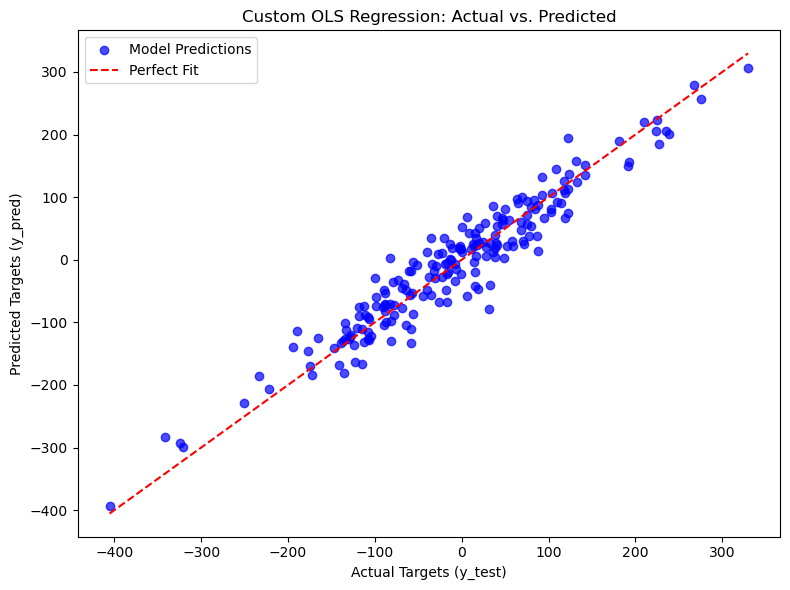

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Model Predictions')

min_val = min(np.min(y_test), np.min(y_pred))
max_val = max(np.max(y_test), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')

plt.xlabel('Actual Targets (y_test)')
plt.ylabel('Predicted Targets (y_pred)')
plt.title('Custom OLS Regression: Actual vs. Predicted')
plt.legend()
plt.tight_layout()

plt.show()

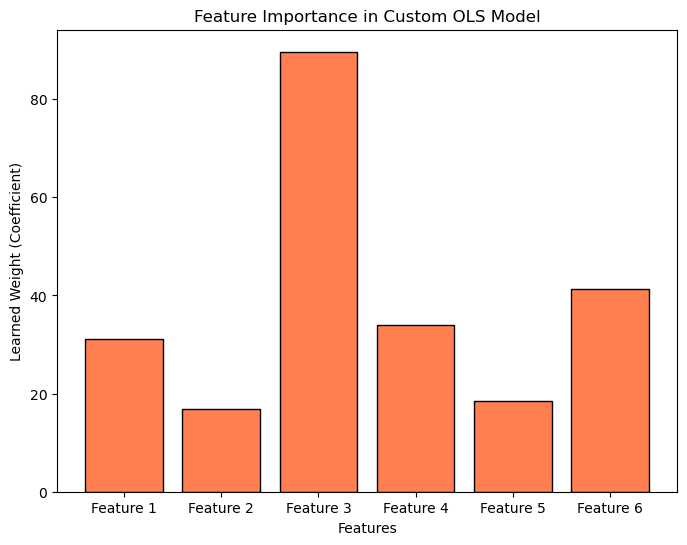

In [12]:
plt.figure(figsize=(8, 6))
features = [f'Feature {i+1}' for i in range(len(my_reg.weights))]

plt.bar(features, my_reg.weights, color='coral', edgecolor='black')

plt.xlabel('Features')
plt.ylabel('Learned Weight (Coefficient)')
plt.title('Feature Importance in Custom OLS Model')
plt.show()

### Conclusion

This project demonstrates the mechanics of Ordinary Least Squares regression by implementing the algorithm from scratch. By translating the Normal Equation $\beta = (X^T X)^{-1} X^T y$ into Python, we directly computed the optimal weights and intercept. Utilizing the Moore-Penrose pseudo-inverse instead of a standard matrix inverse ensures numerical stability, even with highly correlated features. 

The custom implementation achieved an $R^2$ score identical to the scikit-learn model. This exact match mathematically validates our approach and proves that building foundational algorithms from the ground up is a highly effective way to understand the internal logic of professional machine learning libraries.